In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv('../dataset/open-meteo_radiation.csv')
df.head()

,time,shortwave_radiation_instant (W/m²),direct_radiation_instant (W/m²),diffuse_radiation_instant (W/m²),direct_normal_irradiance_instant (W/m²),terrestrial_radiation_instant (W/m²)
0,2019-01-01T00:00,48.2,0.0,48.2,0.0,368.1
1,2019-01-01T01:00,128.6,16.1,112.5,46.1,609.9
2,2019-01-01T02:00,104.4,4.5,99.9,9.0,794.1
3,2019-01-01T03:00,187.5,7.4,180.1,12.2,908.4
4,2019-01-01T04:00,194.4,13.2,181.2,19.9,944.8


In [3]:
df.set_index('time', inplace=True)

df.head()

,shortwave_radiation_instant (W/m²),direct_radiation_instant (W/m²),diffuse_radiation_instant (W/m²),direct_normal_irradiance_instant (W/m²),terrestrial_radiation_instant (W/m²)
time,,,,,
2019-01-01T00:00,48.2,0.0,48.2,0.0,368.1
2019-01-01T01:00,128.6,16.1,112.5,46.1,609.9
2019-01-01T02:00,104.4,4.5,99.9,9.0,794.1
2019-01-01T03:00,187.5,7.4,180.1,12.2,908.4
2019-01-01T04:00,194.4,13.2,181.2,19.9,944.8


In [4]:
print(df.shape)

(8760, 5)


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8760 entries, 2019-01-01T00:00 to 2019-12-31T23:00
Data columns (total 5 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   shortwave_radiation_instant (W/m²)       8760 non-null   float64
 1   direct_radiation_instant (W/m²)          8760 non-null   float64
 2   diffuse_radiation_instant (W/m²)         8760 non-null   float64
 3   direct_normal_irradiance_instant (W/m²)  8760 non-null   float64
 4   terrestrial_radiation_instant (W/m²)     8760 non-null   float64
dtypes: float64(5)
memory usage: 410.6+ KB


/var/folders/97/8bx4_dmx3038pm1qrblmtrl80000gn/T/ipykernel_6545/2567589199.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_data = df.resample('M').mean()


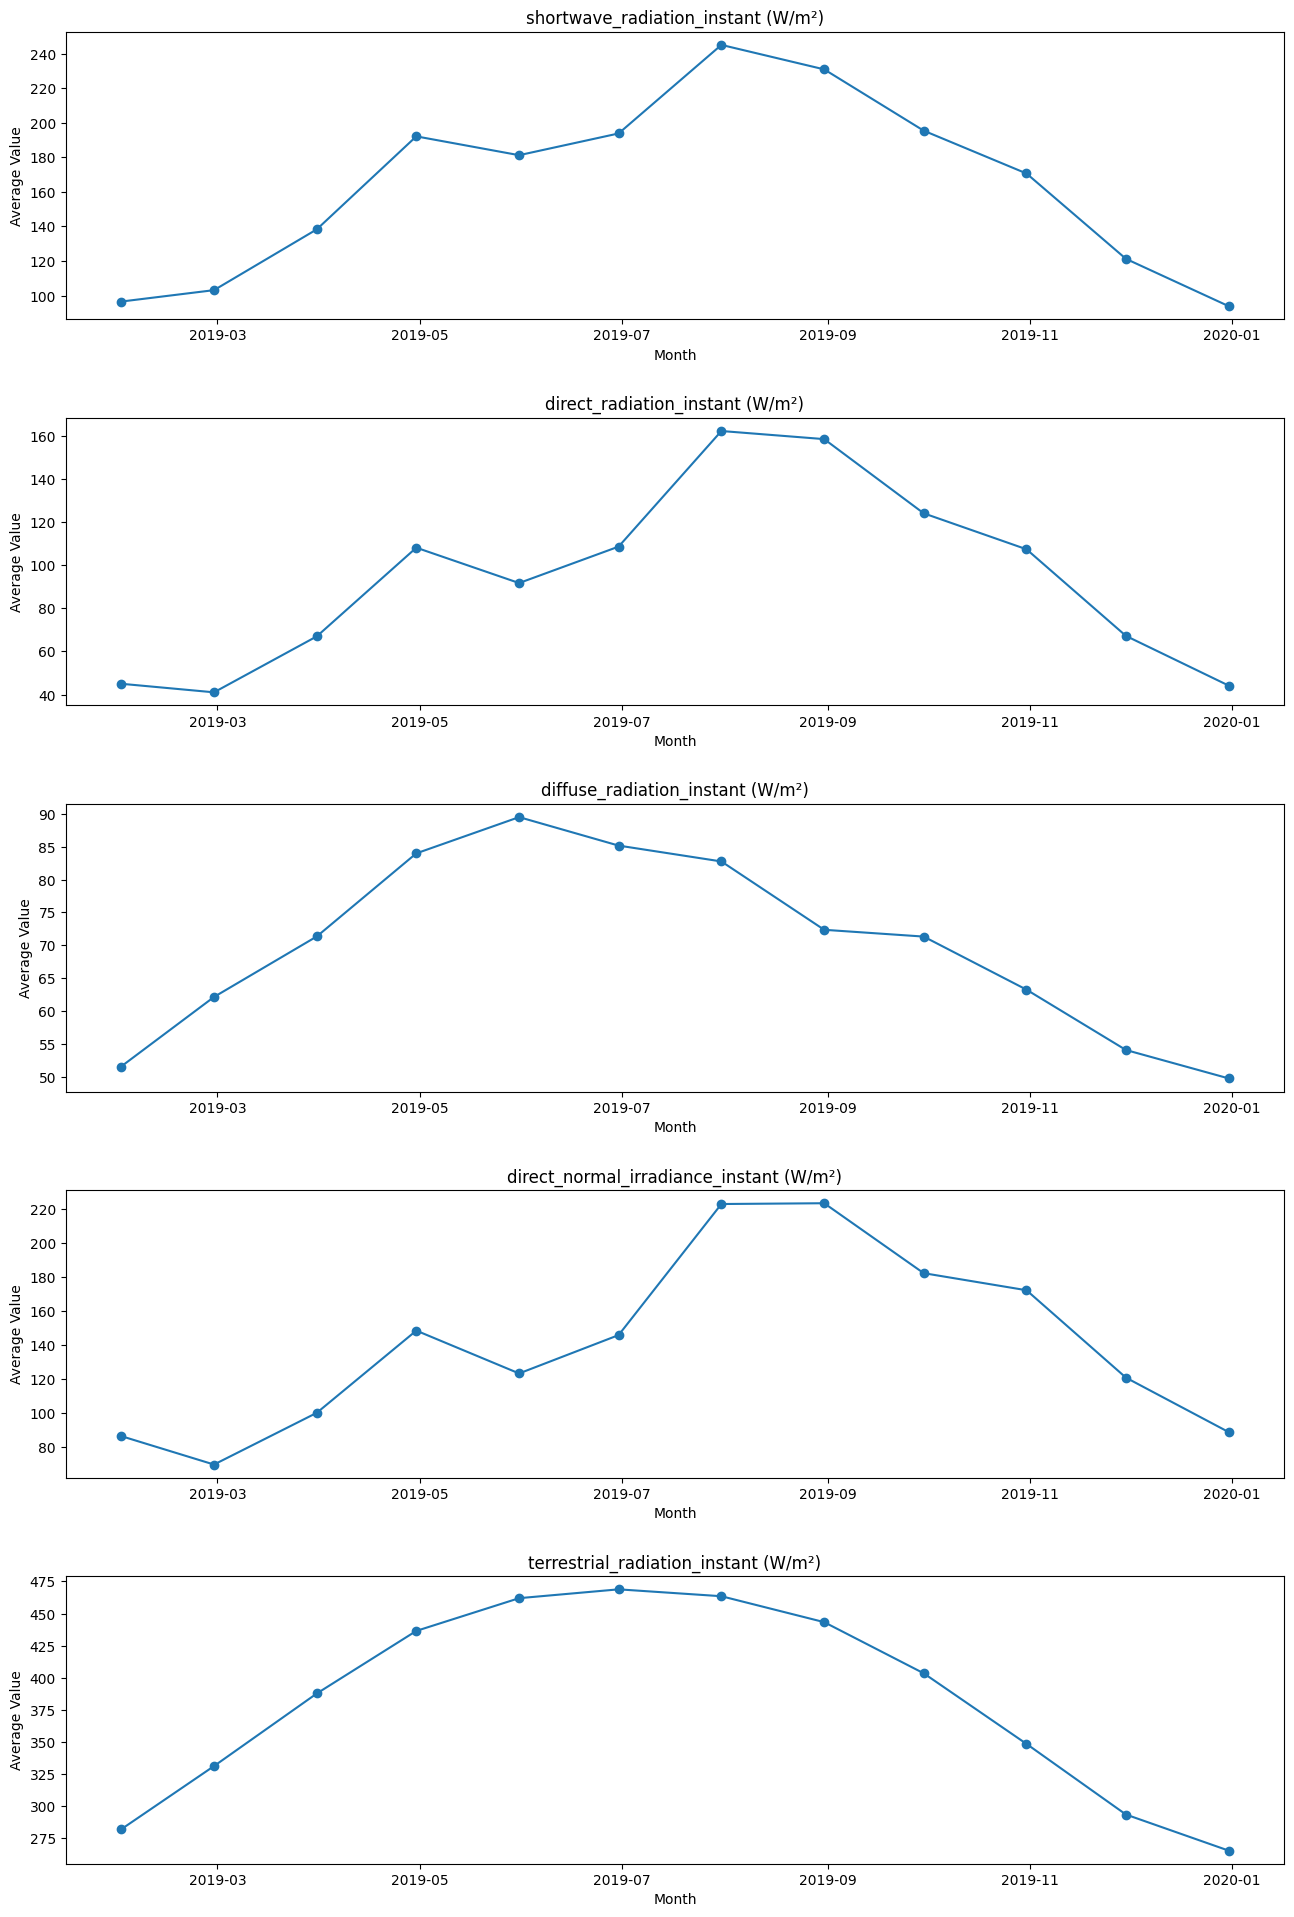

In [8]:
# Pastikan index sudah dalam format datetime
df.index = pd.to_datetime(df.index)

# Resampling data per bulan dengan rata-rata
monthly_data = df.resample('M').mean()

# Setup plot
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(14, 20))
fig.tight_layout(pad=5.0)

# Nama kolom untuk plotting
columns = [
    'shortwave_radiation_instant (W/m²)',
    'direct_radiation_instant (W/m²)',
    'diffuse_radiation_instant (W/m²)',
    'direct_normal_irradiance_instant (W/m²)',
    'terrestrial_radiation_instant (W/m²)'
]

# Loop untuk plotting setiap fitur
for i, column in enumerate(columns):
    axes[i].plot(monthly_data.index, monthly_data[column], marker='o', linestyle='-')
    axes[i].set_title(column)
    axes[i].set_xlabel('Month')
    axes[i].set_ylabel('Average Value')

# Tampilkan plot
plt.show()

In [10]:
df = pd.read_csv('../dataset/open-meteo_weather.csv')
df.head()

,time,temperature_2m (°C),relative_humidity_2m (%),dew_point_2m (°C),apparent_temperature (°C),rain (mm),cloud_cover (%),cloud_cover_low (%),cloud_cover_mid (%),cloud_cover_high (%)
0,2019-01-01T00:00,16.7,82,13.6,15.4,0.1,97,53,20,0
1,2019-01-01T01:00,17.2,85,14.6,16.0,0.1,100,100,42,0
2,2019-01-01T02:00,17.1,80,13.6,15.8,0.1,100,100,47,0
3,2019-01-01T03:00,18.0,77,14.0,16.6,0.0,100,100,43,0
4,2019-01-01T04:00,17.9,78,14.0,16.6,0.1,100,100,42,0


In [11]:
df.set_index('time', inplace=True)

df.head()

,temperature_2m (°C),relative_humidity_2m (%),dew_point_2m (°C),apparent_temperature (°C),rain (mm),cloud_cover (%),cloud_cover_low (%),cloud_cover_mid (%),cloud_cover_high (%)
time,,,,,,,,,
2019-01-01T00:00,16.7,82,13.6,15.4,0.1,97,53,20,0
2019-01-01T01:00,17.2,85,14.6,16.0,0.1,100,100,42,0
2019-01-01T02:00,17.1,80,13.6,15.8,0.1,100,100,47,0
2019-01-01T03:00,18.0,77,14.0,16.6,0.0,100,100,43,0
2019-01-01T04:00,17.9,78,14.0,16.6,0.1,100,100,42,0


In [12]:
print(df.shape)

(8760, 9)


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8760 entries, 2019-01-01T00:00 to 2019-12-31T23:00
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   temperature_2m (°C)        8760 non-null   float64
 1   relative_humidity_2m (%)   8760 non-null   int64  
 2   dew_point_2m (°C)          8760 non-null   float64
 3   apparent_temperature (°C)  8760 non-null   float64
 4   rain (mm)                  8760 non-null   float64
 5   cloud_cover (%)            8760 non-null   int64  
 6   cloud_cover_low (%)        8760 non-null   int64  
 7   cloud_cover_mid (%)        8760 non-null   int64  
 8   cloud_cover_high (%)       8760 non-null   int64  
dtypes: float64(4), int64(5)
memory usage: 684.4+ KB


/var/folders/97/8bx4_dmx3038pm1qrblmtrl80000gn/T/ipykernel_6545/3068003186.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_data = df.resample('M').mean()


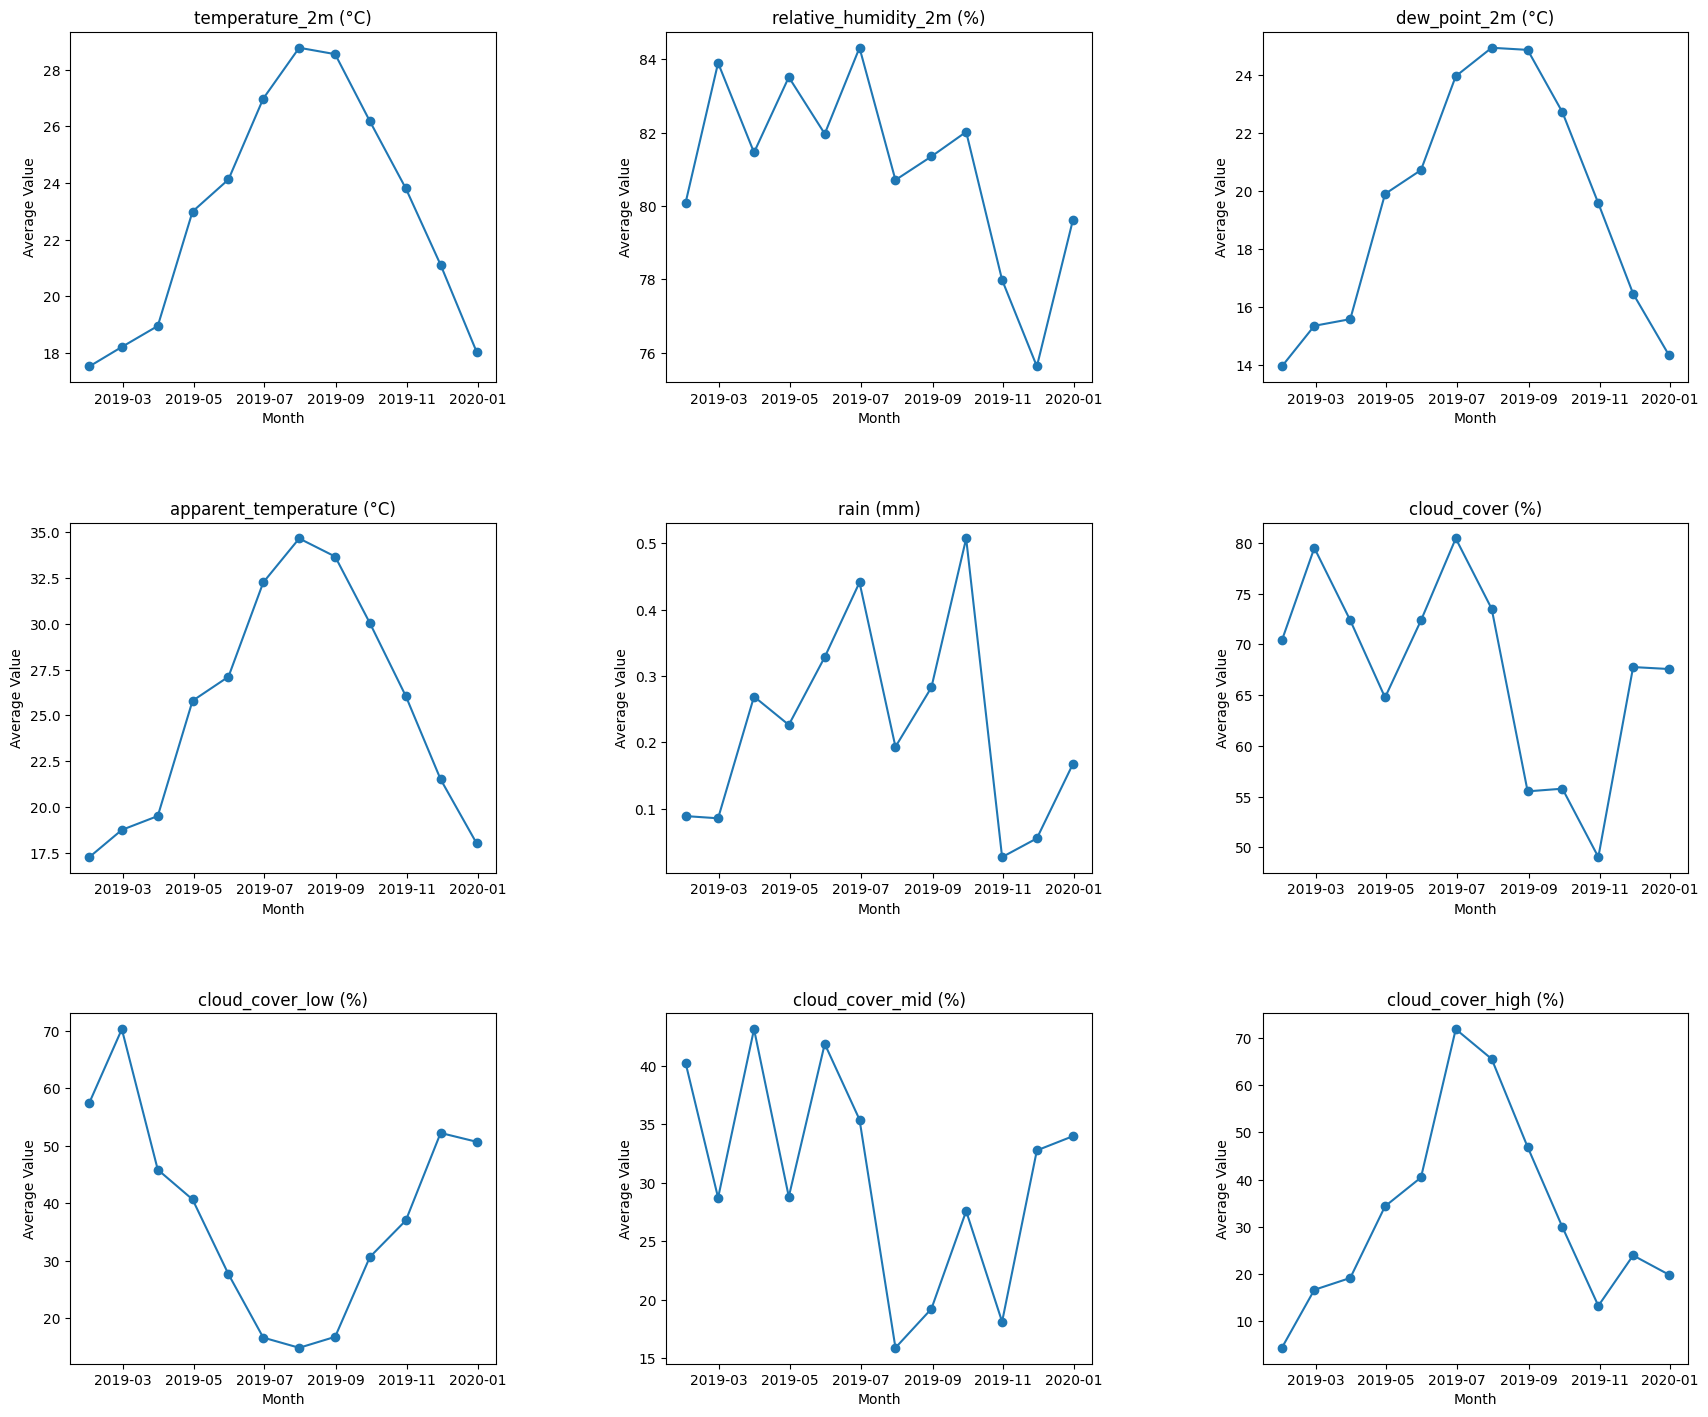

In [15]:
# Pastikan index sudah dalam format datetime
df.index = pd.to_datetime(df.index)

# Resampling data per bulan dengan rata-rata
monthly_data = df.resample('M').mean()

# Setup plot
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 15))
fig.tight_layout(pad=5.0)

# Nama kolom untuk plotting
columns = [
    'temperature_2m (°C)',
    'relative_humidity_2m (%)',
    'dew_point_2m (°C)',
    'apparent_temperature (°C)',
    'rain (mm)',
    'cloud_cover (%)',
    'cloud_cover_low (%)',
    'cloud_cover_mid (%)',
    'cloud_cover_high (%)'
]

# Loop untuk plotting setiap fitur
for i, column in enumerate(columns):
    ax = axes[i // 3, i % 3]  # Mengatur subplot berdasarkan posisi
    ax.plot(monthly_data.index, monthly_data[column], marker='o', linestyle='-')
    ax.set_title(column)
    ax.set_xlabel('Month')
    ax.set_ylabel('Average Value')

# Ajust space between plots
plt.subplots_adjust(hspace=0.4, wspace=0.4)

# Tampilkan plot
plt.show()

In [21]:
import csv

FILE_PATH = "../dataset/dataset_capacity.csv"

# Membuat range waktu dari 2019-01-01 00:00 hingga 2019-12-31 23:00 dengan frekuensi per jam
time_range = pd.date_range(start='2019-01-01 00:00', end='2019-12-31 23:00', freq='H')

# Membaca data dari file
data = []
with open(FILE_PATH, 'r', encoding='utf-8') as file:
    reader = csv.reader(file, delimiter=';')
    next(reader)  # Skip header row

    for row in reader:
        load = row[0].replace(',', '.')  # Mengganti koma dengan titik
        sg = row[1].replace(',', '.')    # Mengganti koma dengan titik
        data.append((float(load), float(sg)))  # Konversi string ke float

# Konversi list menjadi DataFrame
df = pd.DataFrame(data, columns=['Load', 'SG'])

# Memastikan jumlah baris dalam time_range dan df sama
if len(time_range) == len(df):
    df['Time'] = time_range
else:
    print("Warning: The number of time points does not match the number of data rows.")

# Set time as the index
df.set_index('Time', inplace=True)


/var/folders/97/8bx4_dmx3038pm1qrblmtrl80000gn/T/ipykernel_6545/4202958904.py:6: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  time_range = pd.date_range(start='2019-01-01 00:00', end='2019-12-31 23:00', freq='H')


In [22]:
df.head()

,Load,SG
Time,,
2019-01-01 00:00:00,223.449142,0.0
2019-01-01 01:00:00,203.311678,0.0
2019-01-01 02:00:00,180.198849,0.0
2019-01-01 03:00:00,146.232528,0.0
2019-01-01 04:00:00,168.747932,0.0


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 8760 entries, 2019-01-01 00:00:00 to 2019-12-31 23:00:00
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Load    8760 non-null   float64
 1   SG      8760 non-null   float64
dtypes: float64(2)
memory usage: 205.3 KB


In [24]:
print(df.shape)

(8760, 2)


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 8760 entries, 2019-01-01 00:00:00 to 2019-12-31 23:00:00
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Load    8760 non-null   float64
 1   SG      8760 non-null   float64
dtypes: float64(2)
memory usage: 205.3 KB


/var/folders/97/8bx4_dmx3038pm1qrblmtrl80000gn/T/ipykernel_6545/1840429969.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_data = df.resample('M').mean()


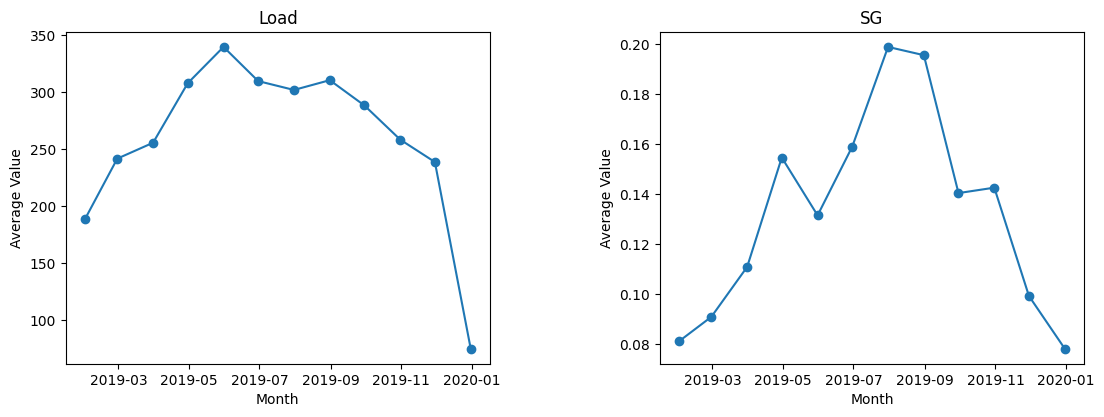

In [26]:
# Pastikan index sudah dalam format datetime
df.index = pd.to_datetime(df.index)

# Resampling data per bulan dengan rata-rata
monthly_data = df.resample('M').mean()

# Setup plot
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))  # Mengubah ukuran dan jumlah subplot
fig.tight_layout(pad=5.0)

# Nama kolom untuk plotting
columns = ['Load', 'SG']

# Loop untuk plotting setiap fitur
for i, column in enumerate(columns):
    ax = axes[i]  # Mengatur subplot berdasarkan posisi
    ax.plot(monthly_data.index, monthly_data[column], marker='o', linestyle='-')
    ax.set_title(column)
    ax.set_xlabel('Month')
    ax.set_ylabel('Average Value')

# Ajust space between plots
plt.subplots_adjust(hspace=0.4, wspace=0.4)

# Tampilkan plot
plt.show()